# Measuring AI-Generated Content in Irish News — Presentation EDA


## Setup

In [25]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [26]:
ROOT = Path.cwd().parent
DATA = ROOT / 'data'
DET_DIR = DATA / 'detection'
DETECTORS = ['perplexity', 'radar', 'binoculars', 'fastdetectgpt']

CATEGORY_ORDER = ['Legacy', 'Counter-consensus']
OUTLET_ORDER = ['rte', 'irish_examiner', 'the_liberal', 'gript']
PERIOD_ORDER = ['pre', 'post']
CATEGORY = {
    'rte': 'Legacy',
    'irish_examiner': 'Legacy',
    'the_liberal': 'Counter-consensus',
    'gript': 'Counter-consensus',
}

META_COLS = [
    'article_id',
    'outlet',
    'published_date',
    'year',
    'month',
    'period',
    'section',
    'author',
    'is_wire',
    'word_count',
]

SCORE_COLS = [f'{detector}_score' for detector in DETECTORS]


In [27]:
def load_scores(detector: str) -> pd.Series:
    """Load one detector's corpus scores keyed by article_id.

    Args:
        detector (str): Detector name.

    Returns:
        pd.Series: Float scores indexed by article_id, named <detector>_score.

    """
    frame = pd.read_csv(DET_DIR / f'{detector}.csv')
    frame.columns = ['id', 'score']
    corpus = frame[frame['id'].str.startswith('corpus:')].copy()
    corpus['article_id'] = corpus['id'].str.removeprefix('corpus:')
    return (
        corpus.set_index('article_id')['score'].astype(float).rename(f'{detector}_score')
    )

In [28]:
df = pd.read_csv(DATA / 'corpus.csv', usecols=META_COLS)
df['category'] = df['outlet'].map(CATEGORY)
df['article_id'] = df['article_id'].astype(str)
for detector in DETECTORS:
    df = df.join(load_scores(detector), on='article_id')

df[['outlet', 'period', 'category', 'word_count', 'article_id', *SCORE_COLS]].head()

,outlet,period,category,word_count,article_id,perplexity_score,radar_score,binoculars_score,fastdetectgpt_score
0,gript,post,Counter-consensus,597,24151,-2.684621,0.010507,-0.988321,0.099189
1,gript,post,Counter-consensus,1082,24152,-2.503251,0.011878,-1.002437,-1.641121
2,gript,post,Counter-consensus,844,24153,-3.096333,0.011502,-1.018009,-1.473422
3,gript,post,Counter-consensus,1010,24154,-3.038991,0.006742,-1.028582,-1.780604
4,gript,post,Counter-consensus,350,47880,-2.859227,0.009843,-0.980833,0.081175


## 1. The corpus and its challenges

Before reading any detector score, we note the structural differences between outlets. Elements like length and wire content change detector scores *independently of AI*, and they line up with the legacy / counter-consensus split.

### 1.1 Composition

The design is deliberately balanced: 5,608 articles per outlet per period, 44,864 total.

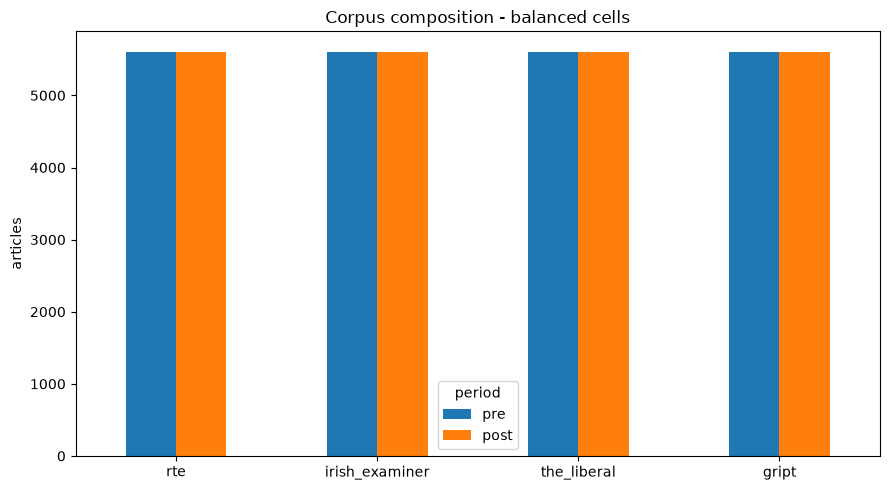

In [29]:
comp = df.pivot_table(index='outlet', columns='period', aggfunc='size', fill_value=0)[
    PERIOD_ORDER
].loc[OUTLET_ORDER]


fig, ax = plt.subplots(figsize=(9, 5))
comp.plot(kind='bar', ax=ax)
ax.set_title('Corpus composition - balanced cells')
ax.set_xlabel('')
ax.set_ylabel('articles')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='period')
fig.tight_layout()

### 1.2 Article length

Median length differs sharply: Gript and the Examiner run long, while **The Liberal is incredibly short-form**. Short text is exactly where zero-shot detectors are least reliable, as we will see, where RADAR false-positives. Because length is confounded with the legacy / counter-consensus split, it is reported alongside every detector result.

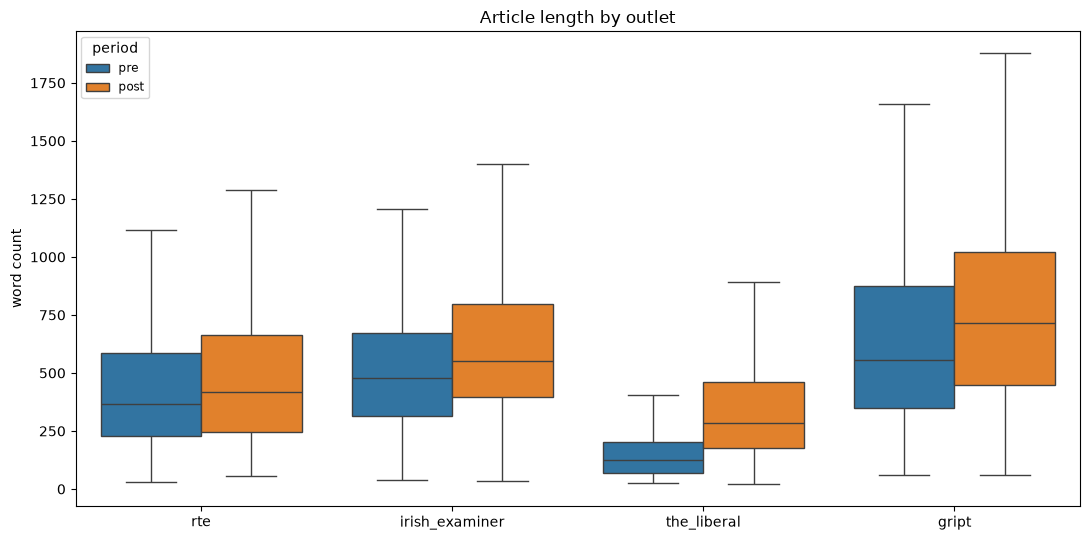

In [30]:
# Word-count distribution by outlet and period (clipped for readability).
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.boxplot(
    data=df,
    x='outlet',
    y='word_count',
    hue='period',
    order=OUTLET_ORDER,
    hue_order=PERIOD_ORDER,
    showfliers=False,
    ax=ax,
)
ax.set_title('Article length by outlet')
ax.set_xlabel('')
ax.set_ylabel('word count')
ax.legend(title='period', fontsize='small')
fig.tight_layout()

### 1.3 Wire and agency content

Wire copy is formulaic and reads as low-perplexity, so it skews detectors. It is concentrated in the **legacy** outlets, while it is near-zero at Liberal and Gript, and rises from pre to post at the Examiner. This is why wire is flagged and kept, and why the headline comparison is also reported wire-excluded.

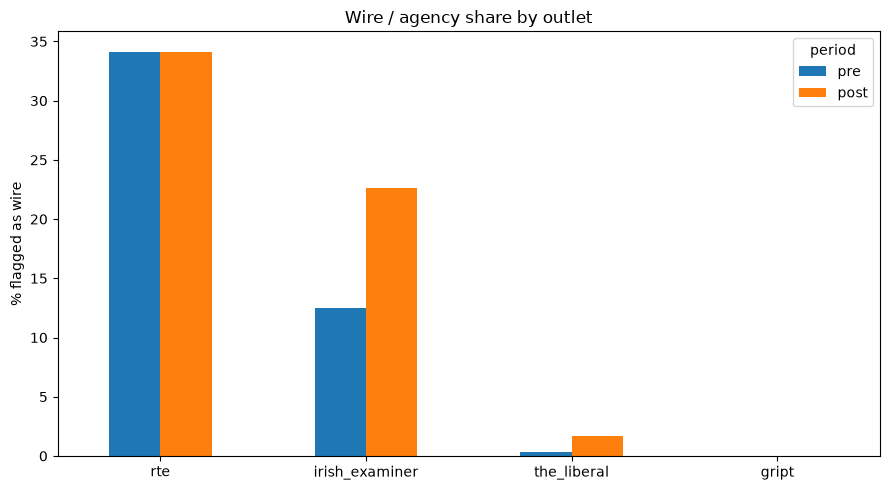

In [32]:
wire = (
    df.groupby(['outlet', 'period'])['is_wire'].mean()
    .unstack()[PERIOD_ORDER].loc[OUTLET_ORDER] * 100
)

fig, ax = plt.subplots(figsize=(9, 5))
wire.plot(kind='bar', ax=ax)
ax.set_title('Wire / agency share by outlet')
ax.set_xlabel('')
ax.set_ylabel('% flagged as wire')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='period')
fig.tight_layout()